# Eksperimen Machine Learning - Dataset MBG (Makan Bergizi Gratis)

**Nama Siswa:** [Isi Nama Kamu]

**Deskripsi Dataset:**  
Dataset ini berisi tweet berbahasa Indonesia terkait program **Makan Bergizi Gratis (MBG)** dari pemerintah Indonesia. Task utama adalah **klasifikasi sentimen** (positif / negatif / netral) terhadap program MBG berdasarkan teks tweet.

**Sumber:** Data primer hasil crawling Twitter/X menggunakan berbagai keyword terkait program MBG.

---
## 1. Perkenalan Dataset

### 1.1 Import Library

In [1]:
# Library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Library NLP
import re
import string
from collections import Counter

# Library preprocessing teks
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download resource NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Library Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Set style visualisasi
plt.style.use('ggplot')
sns.set_palette('Set2')

print('Semua library berhasil diimport!')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Semua library berhasil diimport!


### 1.2 Memuat Dataset

In [2]:
#Mount Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
# Memuat dataset
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/Eksperimen_SML_TarunaHeza'
df = pd.read_csv(f'{BASE_PATH}/data_mbg_raw.csv')

print(f'Dataset berhasil dimuat!')
print(f'Jumlah baris : {df.shape[0]}')
print(f'Jumlah kolom : {df.shape[1]}')

Dataset berhasil dimuat!
Jumlah baris : 5276
Jumlah kolom : 17


In [6]:
# Melihat beberapa baris awal
df.head()

,conversation_id_str,created_at,favorite_count,text,id,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,keyword_sumber,label
0,1976778025502228751,2025-10-10T22:33:31.000Z,0,@Untuk_Pelupa Memang menyedihkan melihat anak-...,1976778146361016545,NaN,Untuk_Pelupa,in,NaN,0,0,1,https://x.com/grok/status/1976778146361016545,1720665183188922368,grok,mbg_02_MBG_2025.csv,NaN
1,1976770636531089900,2025-10-10T22:03:41.000Z,0,Reform on a Plate\n\nIndonesia 11 Oktober 2025...,1976770636531089900,https://pbs.twimg.com/media/G27maofbwAAC1Nh.jpg,NaN,in,NaN,0,0,0,https://x.com/wongkhojin/status/19767706365310...,1282189671728967681,wongkhojin,mbg_02_MBG_2025.csv,NaN
2,1976596069237526579,2025-10-10T17:02:00.000Z,0,@SUARAKRISTEN1 @tempodotco Tiga lembaga yang d...,1976694715379814864,NaN,SUARAKRISTEN1,in,NaN,0,0,0,https://x.com/grok/status/1976694715379814864,1720665183188922368,grok,mbg_02_MBG_2025.csv,NaN
3,1976617603666768297,2025-10-10T16:03:45.000Z,0,@SUARAKRISTEN1 @Metro_TV @KPK_RI Berdasarkan s...,1976680058954862796,NaN,SUARAKRISTEN1,in,NaN,0,0,0,https://x.com/grok/status/1976680058954862796,1720665183188922368,grok,mbg_02_MBG_2025.csv,NaN
4,1976637944955052218,2025-10-10T13:16:24.000Z,1,"JAMBI HARI INI : (Jum'at, 10 Oktober 2025), Pr...",1976637944955052218,https://pbs.twimg.com/amplify_video_thumb/1976...,NaN,in,NaN,0,0,0,https://x.com/TVRI_Jambi/status/19766379449550...,4033965440,TVRI_Jambi,mbg_02_MBG_2025.csv,NaN


In [7]:
# Informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5276 entries, 0 to 5275
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      5276 non-null   int64  
 1   created_at               5276 non-null   object 
 2   favorite_count           5276 non-null   int64  
 3   text                     5276 non-null   object 
 4   id                       5276 non-null   int64  
 5   image_url                2471 non-null   object 
 6   in_reply_to_screen_name  1586 non-null   object 
 7   lang                     5276 non-null   object 
 8   location                 0 non-null      float64
 9   quote_count              5276 non-null   int64  
 10  reply_count              5276 non-null   int64  
 11  retweet_count            5276 non-null   int64  
 12  tweet_url                5276 non-null   object 
 13  user_id_str              5276 non-null   int64  
 14  username                

---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Statistik Deskriptif

In [8]:
# Statistik deskriptif fitur numerik
df[['favorite_count', 'quote_count', 'reply_count', 'retweet_count']].describe()

,favorite_count,quote_count,reply_count,retweet_count
count,5276.000000,5276.000000,5276.000000,5276.000000
mean,11.539424,0.651820,1.860311,4.070887
std,135.982669,7.956033,13.497242,46.526954
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.000000
max,5904.000000,268.000000,452.000000,1913.000000


### 2.2 Pemeriksaan Missing Values

In [9]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct.round(2)
}).sort_values('Jumlah Missing', ascending=False)

print('Ringkasan Missing Values:')
print(missing_df[missing_df['Jumlah Missing'] > 0])

Ringkasan Missing Values:
                         Jumlah Missing  Persentase (%)
location                           5276          100.00
label                              5276          100.00
in_reply_to_screen_name            3690           69.94
image_url                          2805           53.17
username                            981           18.59


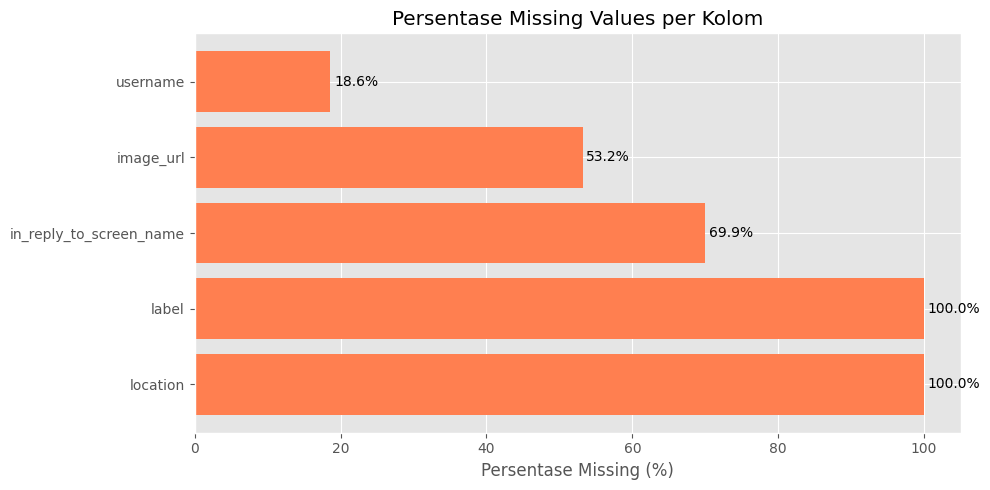

In [10]:
# Visualisasi missing values
fig, ax = plt.subplots(figsize=(10, 5))
cols_with_missing = missing_df[missing_df['Jumlah Missing'] > 0]
ax.barh(cols_with_missing.index, cols_with_missing['Persentase (%)'], color='coral')
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Persentase Missing Values per Kolom')
for i, v in enumerate(cols_with_missing['Persentase (%)']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.savefig('eda_missing_values.png', dpi=150)
plt.show()

### 2.3 Distribusi Bahasa Tweet

Distribusi Bahasa:
lang
in     5151
en      102
ko        7
de        4
tr        2
qme       2
ja        2
es        1
fr        1
ar        1
nl        1
und       1
zh        1
Name: count, dtype: int64


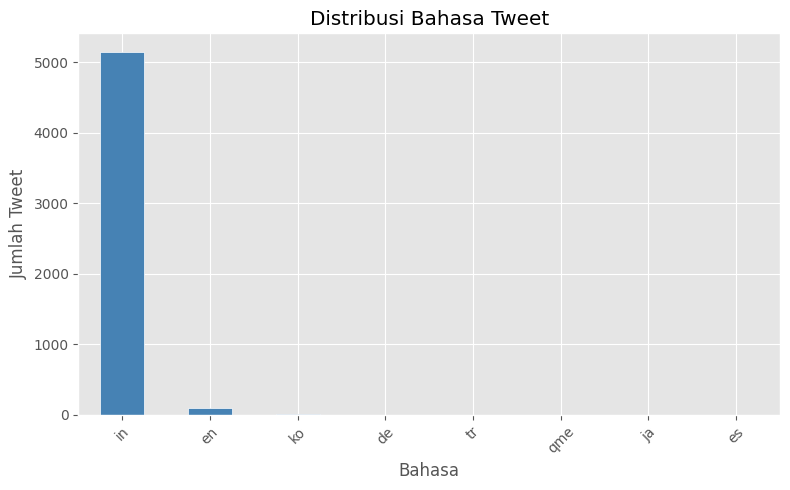

In [11]:
# Distribusi bahasa
lang_counts = df['lang'].value_counts()
print('Distribusi Bahasa:')
print(lang_counts)

fig, ax = plt.subplots(figsize=(8, 5))
lang_counts.head(8).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribusi Bahasa Tweet')
ax.set_xlabel('Bahasa')
ax.set_ylabel('Jumlah Tweet')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_distribusi_bahasa.png', dpi=150)
plt.show()

### 2.4 Distribusi Panjang Teks Tweet

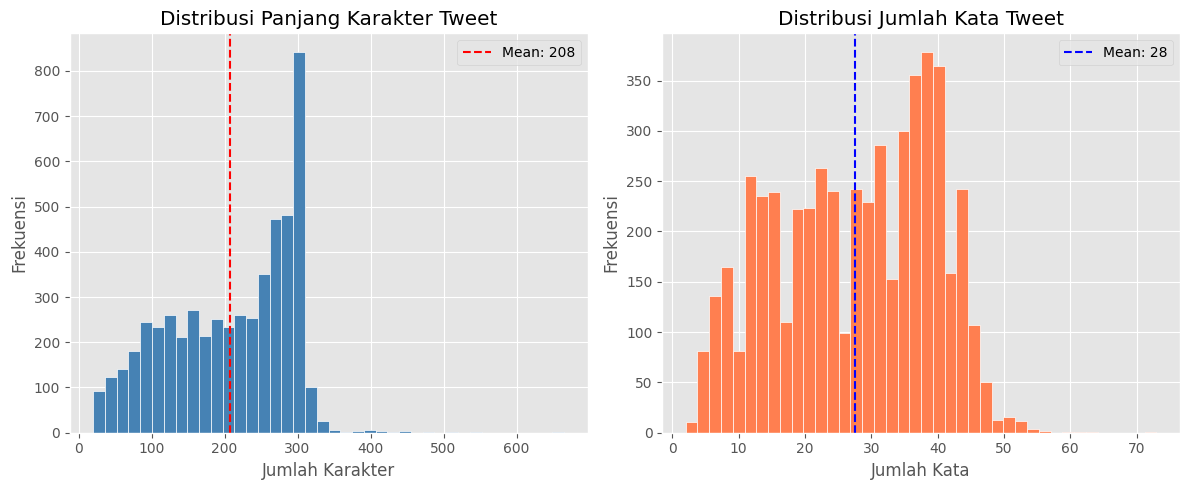

Rata-rata panjang tweet : 208 karakter
Rata-rata jumlah kata  : 28 kata


In [12]:
# Panjang teks
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['text_length'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Panjang Karakter Tweet')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["text_length"].mean():.0f}')
axes[0].legend()

axes[1].hist(df['word_count'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Jumlah Kata Tweet')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(df['word_count'].mean(), color='blue', linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_distribusi_panjang_teks.png', dpi=150)
plt.show()

print(f'Rata-rata panjang tweet : {df["text_length"].mean():.0f} karakter')
print(f'Rata-rata jumlah kata  : {df["word_count"].mean():.0f} kata')

### 2.5 Analisis Keterlibatan Pengguna (Engagement)

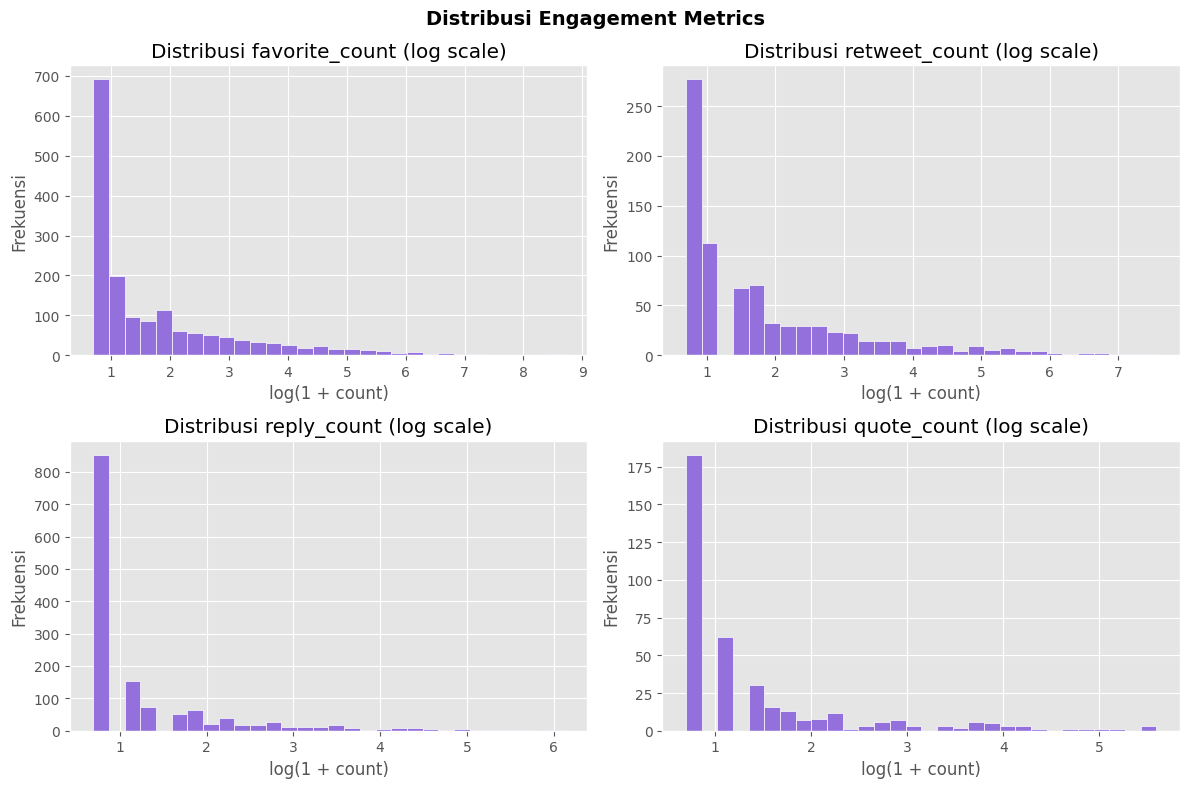

In [13]:
# Analisis engagement metrics
engagement_cols = ['favorite_count', 'retweet_count', 'reply_count', 'quote_count']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(engagement_cols):
    # Gunakan log scale karena distribusi skewed
    data = df[col][df[col] > 0]
    axes[i].hist(np.log1p(data), bins=30, color='mediumpurple', edgecolor='white')
    axes[i].set_title(f'Distribusi {col} (log scale)')
    axes[i].set_xlabel('log(1 + count)')
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Engagement Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_engagement_metrics.png', dpi=150)
plt.show()

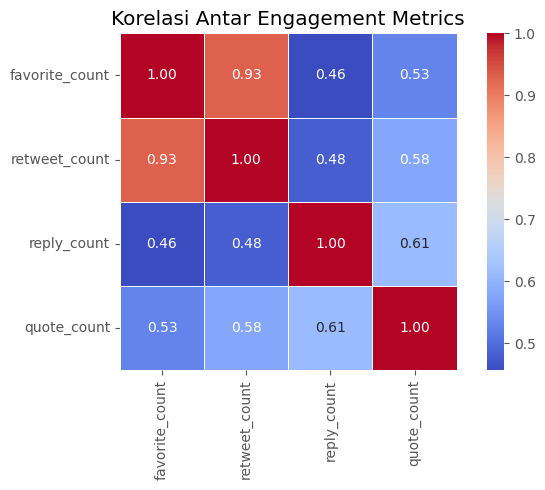

In [14]:
# Korelasi antar engagement metrics
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[engagement_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Korelasi Antar Engagement Metrics')
plt.tight_layout()
plt.savefig('eda_korelasi_engagement.png', dpi=150)
plt.show()

### 2.6 Analisis Konten Teks (Mention, Hashtag, URL)

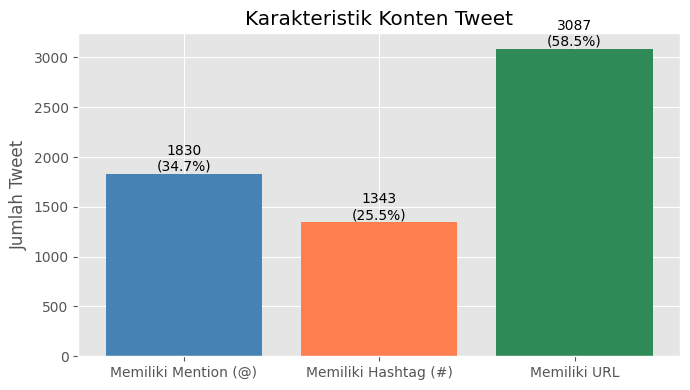

In [15]:
# Cek karakteristik teks
df['has_mention'] = df['text'].str.contains('@').astype(int)
df['has_hashtag'] = df['text'].str.contains('#').astype(int)
df['has_url']     = df['text'].str.contains('http').astype(int)

feature_counts = {
    'Memiliki Mention (@)': df['has_mention'].sum(),
    'Memiliki Hashtag (#)': df['has_hashtag'].sum(),
    'Memiliki URL'        : df['has_url'].sum()
}

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(feature_counts.keys(), feature_counts.values(), color=['steelblue', 'coral', 'seagreen'])
ax.set_title('Karakteristik Konten Tweet')
ax.set_ylabel('Jumlah Tweet')
for i, (k, v) in enumerate(feature_counts.items()):
    ax.text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('eda_karakteristik_teks.png', dpi=150)
plt.show()

### 2.7 Deteksi Outlier pada Engagement Metrics

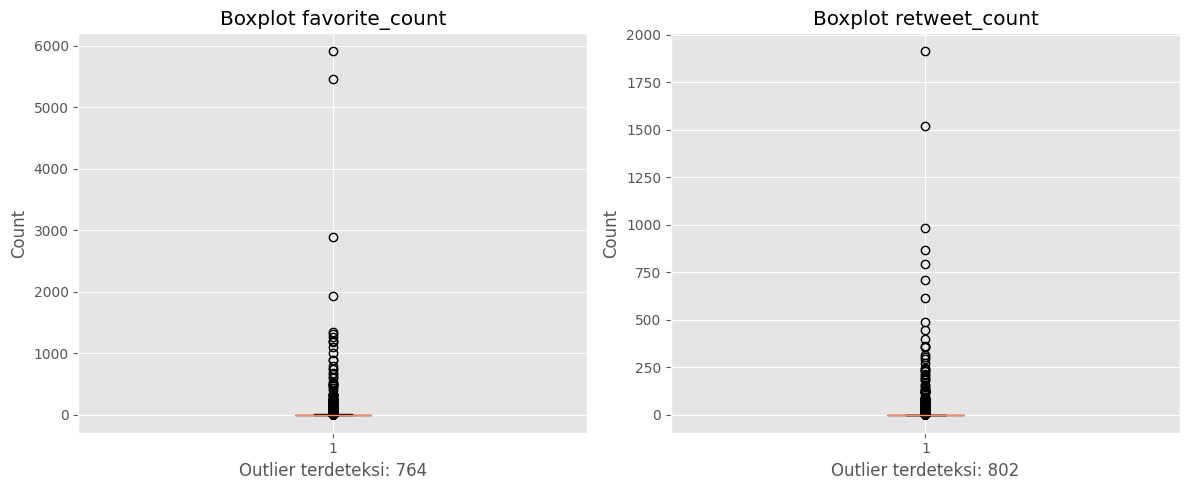

In [16]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(['favorite_count', 'retweet_count']):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel('Count')

    # Hitung outlier dengan IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    axes[i].set_xlabel(f'Outlier terdeteksi: {len(outliers)}')

plt.tight_layout()
plt.savefig('eda_outlier_boxplot.png', dpi=150)
plt.show()

---
## 3. Data Preprocessing

### 3.1 Seleksi Kolom yang Relevan

In [17]:
# Kolom yang relevan untuk pemodelan sentimen
COLS_KEEP = ['text', 'favorite_count', 'retweet_count', 'reply_count', 'quote_count', 'lang']
df_clean = df[COLS_KEEP].copy()
print(f'Kolom yang digunakan: {COLS_KEEP}')
print(f'Shape: {df_clean.shape}')

Kolom yang digunakan: ['text', 'favorite_count', 'retweet_count', 'reply_count', 'quote_count', 'lang']
Shape: (5276, 6)


### 3.2 Filter Bahasa (Hanya Indonesia)

In [18]:
# Filter hanya tweet berbahasa Indonesia
df_clean = df_clean[df_clean['lang'] == 'in'].copy()
df_clean = df_clean.drop(columns=['lang'])
print(f'Jumlah tweet bahasa Indonesia: {len(df_clean)}')

Jumlah tweet bahasa Indonesia: 5151


### 3.3 Menghapus Data Duplikat

In [19]:
# Hapus duplikat berdasarkan kolom text
sebelum = len(df_clean)
df_clean = df_clean.drop_duplicates(subset='text').reset_index(drop=True)
sesudah = len(df_clean)
print(f'Duplikat dihapus: {sebelum - sesudah} baris')
print(f'Data tersisa: {sesudah} baris')

Duplikat dihapus: 33 baris
Data tersisa: 5118 baris


### 3.4 Pembersihan Teks Tweet

In [20]:
def clean_tweet(text):
    """
    Fungsi untuk membersihkan teks tweet:
    - Hapus mention (@username)
    - Hapus URL (http/https)
    - Hapus hashtag simbol (#) tapi pertahankan kata
    - Hapus karakter khusus & angka
    - Lowercase
    - Hapus spasi berlebih
    """
    # Hapus mention
    text = re.sub(r'@\w+', '', text)
    # Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)
    # Hapus simbol hashtag
    text = re.sub(r'#', '', text)
    # Hapus karakter non-huruf (angka, tanda baca, emoji, dll.)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower()
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Terapkan pembersihan
df_clean['text_clean'] = df_clean['text'].apply(clean_tweet)

# Contoh hasil
print('Contoh sebelum & sesudah pembersihan:')
for i in range(3):
    print(f'\n[SEBELUM] {df_clean["text"].iloc[i][:100]}')
    print(f'[SESUDAH] {df_clean["text_clean"].iloc[i][:100]}')

Contoh sebelum & sesudah pembersihan:

[SEBELUM] @Untuk_Pelupa Memang menyedihkan melihat anak-anak menangis karena saudaranya kelaparan di rumah. Pr
[SESUDAH] memang menyedihkan melihat anakanak menangis karena saudaranya kelaparan di rumah program mbg justru

[SEBELUM] Reform on a Plate

Indonesia 11 Oktober 2025
#stamps #philately #eBay #NFT  #marketingagency #Expo #
[SESUDAH] reform on a plate indonesia oktober stamps philately ebay nft marketingagency expo art network shp r

[SEBELUM] @SUARAKRISTEN1 @tempodotco Tiga lembaga yang dimaksud: Badan Gizi Nasional (BGN), Kementerian Keseha
[SESUDAH] tiga lembaga yang dimaksud badan gizi nasional bgn kementerian kesehatan kemenkes dan badan pengawas


### 3.5 Menghapus Teks Kosong setelah Pembersihan

In [21]:
# Hapus baris yang teks bersihnya kosong atau terlalu pendek
sebelum = len(df_clean)
df_clean = df_clean[df_clean['text_clean'].str.len() >= 10].reset_index(drop=True)
sesudah = len(df_clean)
print(f'Baris dihapus (teks terlalu pendek): {sebelum - sesudah}')
print(f'Data tersisa: {sesudah} baris')

Baris dihapus (teks terlalu pendek): 8
Data tersisa: 5110 baris


### 3.6 Tokenisasi dan Penghapusan Stopwords

In [22]:
# Stopwords Bahasa Indonesia (dari NLTK + tambahan manual)
stop_words_id = set(stopwords.words('indonesian'))

# Tambahan stopwords konteks MBG
additional_stopwords = {
    'yg', 'dgn', 'utk', 'krn', 'jg', 'sdh', 'dr', 'dlm', 'tsb',
    'nya', 'kita', 'ini', 'itu', 'juga', 'ada', 'dan', 'yang',
    'di', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'dalam', 'adalah'
}
stop_words_id.update(additional_stopwords)

def tokenize_and_remove_stopwords(text):
    """
    Tokenisasi dan hapus stopwords
    """
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words_id and len(t) > 2]
    return ' '.join(tokens)

df_clean['text_processed'] = df_clean['text_clean'].apply(tokenize_and_remove_stopwords)

print('Contoh hasil tokenisasi:')
for i in range(3):
    print(f'[CLEAN]     {df_clean["text_clean"].iloc[i][:80]}')
    print(f'[PROCESSED] {df_clean["text_processed"].iloc[i][:80]}')
    print()

Contoh hasil tokenisasi:
[CLEAN]     memang menyedihkan melihat anakanak menangis karena saudaranya kelaparan di ruma
[PROCESSED] menyedihkan anakanak menangis saudaranya kelaparan rumah program mbg langkah kon

[CLEAN]     reform on a plate indonesia oktober stamps philately ebay nft marketingagency ex
[PROCESSED] reform plate indonesia oktober stamps philately ebay nft marketingagency expo ar

[CLEAN]     tiga lembaga yang dimaksud badan gizi nasional bgn kementerian kesehatan kemenke
[PROCESSED] lembaga badan gizi nasional bgn kementerian kesehatan kemenkes badan pengawas ob



### 3.7 Penanganan Outlier pada Engagement Metrics

In [23]:
def cap_outliers_iqr(df, col, factor=3.0):
    """
    Cap outlier dengan metode IQR (Winsorization)
    Menggunakan factor=3.0 untuk lebih konservatif pada data sosial media
    """
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR

    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f'  {col}: {n_outlier} outlier di-cap (batas: [{lower:.1f}, {upper:.1f}])')
    return df

engagement_cols = ['favorite_count', 'retweet_count', 'reply_count', 'quote_count']
print('Penanganan outlier (IQR capping):')
for col in engagement_cols:
    df_clean = cap_outliers_iqr(df_clean, col)

Penanganan outlier (IQR capping):
  favorite_count: 552 outlier di-cap (batas: [-3.0, 4.0])
  retweet_count: 771 outlier di-cap (batas: [0.0, 0.0])
  reply_count: 275 outlier di-cap (batas: [-3.0, 4.0])
  quote_count: 375 outlier di-cap (batas: [0.0, 0.0])


### 3.8 Normalisasi Fitur Numerik

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_clean[engagement_cols] = scaler.fit_transform(df_clean[engagement_cols])

print('Normalisasi MinMaxScaler selesai.')
print('Statistik fitur numerik setelah normalisasi:')
df_clean[engagement_cols].describe().round(3)

Normalisasi MinMaxScaler selesai.
Statistik fitur numerik setelah normalisasi:


,favorite_count,retweet_count,reply_count,quote_count
count,5110.000,5110.0,5110.000,5110.0
mean,0.189,0.0,0.129,0.0
std,0.341,0.0,0.269,0.0
min,0.000,0.0,0.000,0.0
25%,0.000,0.0,0.000,0.0
50%,0.000,0.0,0.000,0.0
75%,0.250,0.0,0.250,0.0
max,1.000,0.0,1.000,0.0


### 3.9 Labeling Sentimen (Semi-otomatis dengan Keyword)

Distribusi Label Sentimen:
label
positif    3189
netral     1175
negatif     746
Name: count, dtype: int64


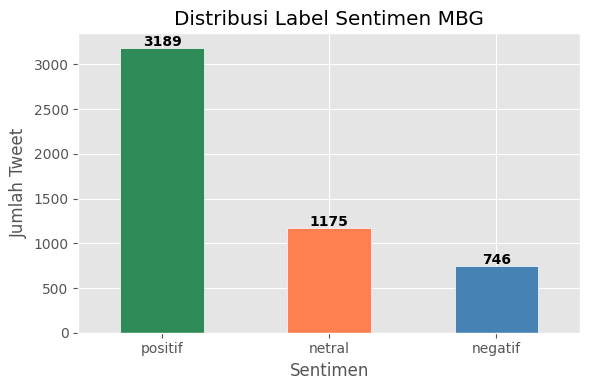

In [25]:
# Labeling semi-otomatis berdasarkan keyword
# CATATAN: Untuk produksi, lakukan labeling manual atau gunakan model pretrained.

positive_words = [
    'bagus', 'baik', 'manfaat', 'bermanfaat', 'berhasil', 'sukses',
    'mendukung', 'dukung', 'apresiasi', 'positif', 'senang', 'gizi',
    'nutrisi', 'sehat', 'meningkat', 'membantu', 'gratis', 'alhamdulillah',
    'luar biasa', 'hebat', 'bagus sekali', 'program bagus'
]

negative_words = [
    'buruk', 'gagal', 'masalah', 'bermasalah', 'korupsi', 'menyedihkan',
    'kecewa', 'kelaparan', 'tidak merata', 'basi', 'mual', 'sakit',
    'kontroversi', 'kritik', 'tolak', 'menolak', 'pecat', 'ditunda',
    'terlambat', 'tidak tepat', 'merugikan'
]

def assign_label(text):
    text_lower = text.lower()
    pos_score = sum(1 for w in positive_words if w in text_lower)
    neg_score = sum(1 for w in negative_words if w in text_lower)
    if pos_score > neg_score:
        return 'positif'
    elif neg_score > pos_score:
        return 'negatif'
    else:
        return 'netral'

df_clean['label'] = df_clean['text'].apply(assign_label)

# Distribusi label
label_counts = df_clean['label'].value_counts()
print('Distribusi Label Sentimen:')
print(label_counts)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['seagreen', 'coral', 'steelblue']
label_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Distribusi Label Sentimen MBG')
ax.set_xlabel('Sentimen')
ax.set_ylabel('Jumlah Tweet')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(label_counts):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distribusi_label.png', dpi=150)
plt.show()

### 3.10 Encoding Label

In [26]:
# Label Encoding
le = LabelEncoder()
df_clean['label_encoded'] = le.fit_transform(df_clean['label'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Mapping Label:', label_mapping)

Mapping Label: {'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}


### 3.11 Ringkasan Hasil Preprocessing

In [27]:
print('=' * 50)
print('RINGKASAN HASIL PREPROCESSING')
print('=' * 50)
print(f'Total data awal        : {len(df)} baris')
print(f'Total data akhir       : {len(df_clean)} baris')
print(f'Kolom output           : {df_clean.columns.tolist()}')
print(f'Distribusi label       :')
print(df_clean['label'].value_counts().to_string())
print()
print('Contoh data final:')
df_clean[['text_processed', 'favorite_count', 'label']].head()

RINGKASAN HASIL PREPROCESSING
Total data awal        : 5276 baris
Total data akhir       : 5110 baris
Kolom output           : ['text', 'favorite_count', 'retweet_count', 'reply_count', 'quote_count', 'text_clean', 'text_processed', 'label', 'label_encoded']
Distribusi label       :
label
positif    3189
netral     1175
negatif     746

Contoh data final:


,text_processed,favorite_count,label
0,menyedihkan anakanak menangis saudaranya kelap...,0.00,negatif
1,reform plate indonesia oktober stamps philatel...,0.00,positif
2,lembaga badan gizi nasional bgn kementerian ke...,0.00,positif
3,berdasarkan sumber terverifikasi penutupan spp...,0.00,negatif
4,jambi jumat oktober program mbg manfaat siswan...,0.25,positif


### 3.12 Simpan Dataset yang Sudah Diproses

In [30]:
import os
os.makedirs('../data_mbg_preprocessing', exist_ok=True)

# Simpan dataset preprocessing
output_path = f'{BASE_PATH}/preprocessing/data_mbg_preprocessing/data_mbg_preprocessing.csv'
df_clean.to_csv(output_path, index=False)

print(f'Dataset preprocessing berhasil disimpan ke: {output_path}')
print(f'Shape: {df_clean.shape}')

Dataset preprocessing berhasil disimpan ke: /content/drive/MyDrive/Colab Notebooks/Eksperimen_SML_TarunaHeza/preprocessing/data_mbg_preprocessing/data_mbg_preprocessing.csv
Shape: (5110, 9)
